I will reproduce the Gross's 13 and 17 qubit code results

In [1]:
import qutip
import matplotlib
from qutip.piqs.piqs  import *
import numpy as np
import os
import time
import gc
os.environ["MOSEKLM_LICENSE_FILE"] = "/Users/46668993/Desktop/qer/mosek/mosek.lic"  # adjust path
from codes.noisemodel import*
from codes.codewords import*
from codes.optimisation import*
import matplotlib.pyplot as plt

Processing gamma=1.00e-05
  Global kraus in 5.45s
  Global optimise in 37.82s
  Local kraus in 5.31s
  Local optimise in 29.10s
Processing gamma=2.15e-05
  Global kraus in 5.05s
  Global optimise in 52.37s
  Local kraus in 5.27s
  Local optimise in 44.04s
Processing gamma=4.64e-05
  Global kraus in 5.14s
  Global optimise in 58.69s
  Local kraus in 5.11s
  Local optimise in 47.12s
Processing gamma=1.00e-04
  Global kraus in 6.08s
  Global optimise in 57.74s
  Local kraus in 5.17s
  Local optimise in 68.01s
Processing gamma=2.15e-04
  Global kraus in 5.67s
  Global optimise in 37.52s
  Local kraus in 5.20s
  Local optimise in 46.33s
Processing gamma=4.64e-04
  Global kraus in 6.16s
  Global optimise in 33.70s
  Local kraus in 5.41s
  Local optimise in 64.67s
Processing gamma=1.00e-03
  Global kraus in 6.13s
  Global optimise in 28.97s
  Local kraus in 6.13s
  Local optimise in 46.68s
Processing gamma=2.15e-03
  Global kraus in 6.47s
  Global optimise in 32.47s
  Local kraus in 5.53s
  L

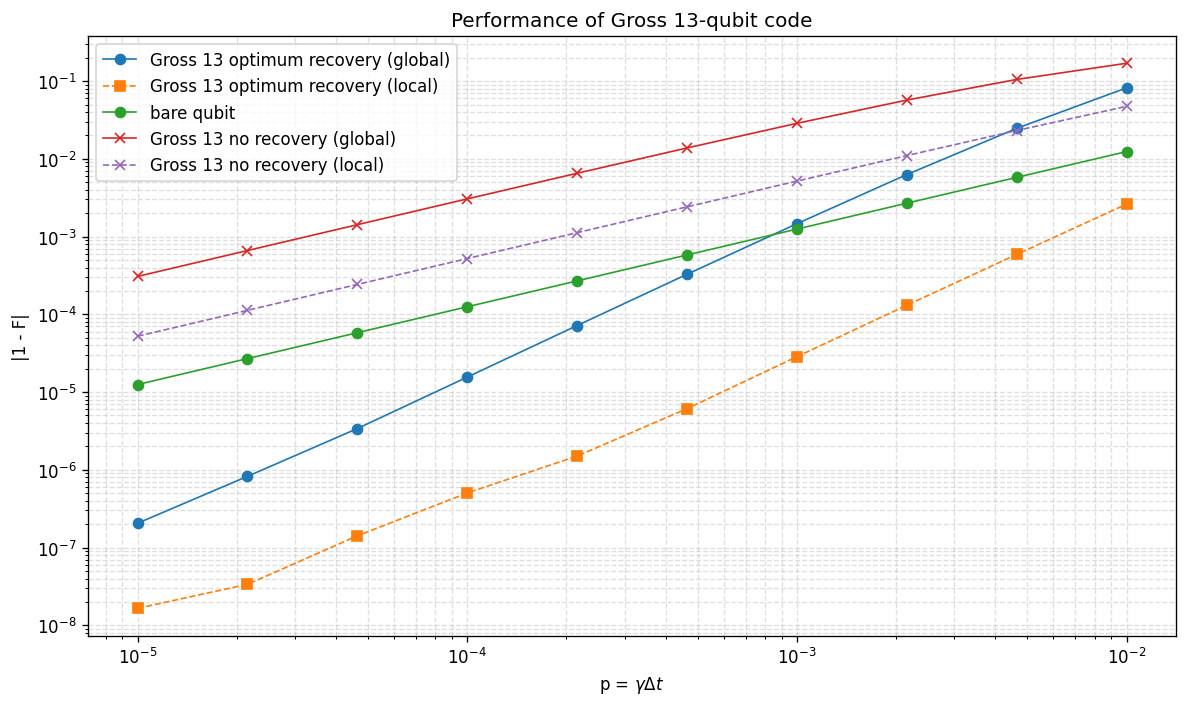

In [2]:
gamma = np.logspace(-5, -2, 10)
dt = 1
p_vals = np.array(gamma) * dt

plt.figure(figsize=(10, 6), dpi = 120)

#bare qubit for comparison
rho_bare = 0.5 * qeye(2)
infids_bare_global = []

#method: kraus or choi
method = 'choi'
method_norecovery = 'kraus'

# Gross 13-qubit code
num_qubits = 13       # The actual number of physical qubits
[rho, l0, l1]  = gross_13_piqs()
infids_global = []
infids_local = []
infids_norecovery_global = []
infids_norecovery_local = []

for g in gamma:
    print(f"Processing gamma={g:.2e}")

    try:
        # Global depolarizing
        t0 = time.perf_counter()
        kraus_global = noisemodel('global symmetric depolarizing', num_qubits, g, dt, method)
        t1 = time.perf_counter()
        print(f"  Global kraus in {t1 - t0:.2f}s")

        fid_global = optimise(l0, l1, kraus_global, solver='mosek')
        t2 = time.perf_counter()
        print(f"  Global optimise in {t2 - t1:.2f}s")
        
        infids_global.append(abs(1.0 - float(fid_global)))

        #bgm code without recovery operation
        infids_norecovery_global.append(abs(1.0 - float(no_recovery(rho, noisemodel('global symmetric depolarizing', num_qubits, g, dt, method_norecovery)))))

        #bare qubit infidelity for comparison
        fid_bare_global = optimise(qutip.basis(2,0), qutip.basis(2,1), noisemodel('global symmetric depolarizing',1,g,dt,method))
        infids_bare_global.append(abs(1.0 - float(fid_bare_global)))
        
        # Delete large objects immediately after use
        del kraus_global
        gc.collect()  # Force garbage collection
        
    except Exception as e:
        print(f"  ERROR (global): {e}")
        infids_global.append(np.nan)

    try:
        # Local depolarizing
        t3 = time.perf_counter()
        kraus_local = noisemodel('local symmetric depolarizing', num_qubits, g, dt, method)
        t4 = time.perf_counter()
        print(f"  Local kraus in {t4 - t3:.2f}s")

        fid_local = optimise(l0, l1, kraus_local, solver='mosek')
        t5 = time.perf_counter()
        print(f"  Local optimise in {t5 - t4:.2f}s")
        
        infids_local.append(abs(1.0 - float(fid_local)))

        #bgm code without recovery operation
        infids_norecovery_local.append(abs(1.0 - float(no_recovery(rho, noisemodel('local symmetric depolarizing', num_qubits, g, dt, method_norecovery)))))
        
        # Delete large objects immediately after use
        del kraus_local
        gc.collect()  # Force garbage collection
        
    except Exception as e:
        print(f"  ERROR (local): {e}")
        infids_local.append(np.nan)

# Process results
infids_global = np.array(infids_global, dtype=float) #bgm code after recovery
infids_bare_global = np.array(infids_bare_global, dtype=float) #bare qubit
infids_local = np.array(infids_local, dtype=float) #bgm code after recovery
infids_norecovery_global = np.array(infids_norecovery_global, dtype=float)#bgm code without recovery
infids_norecovery_local = np.array(infids_norecovery_local, dtype=float)#bgm code without recovery

mask_global = (infids_global > 0) & np.isfinite(infids_global)
mask_local = (infids_local > 0) & np.isfinite(infids_local)
mask_bare_global = (infids_bare_global > 0) & np.isfinite(infids_bare_global)
mask_infids_norecovery_global = (infids_norecovery_global > 0) & np.isfinite(infids_norecovery_global)
mask_infids_norecovery_local = (infids_norecovery_local > 0) & np.isfinite(infids_norecovery_local)

if np.any(mask_global):
    plt.loglog(p_vals[mask_global], infids_global[mask_global], "o-", lw=1, label=f"Gross 13 optimum recovery (global)")
if np.any(mask_local):
    plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"Gross 13 optimum recovery (local)")
if np.any(mask_bare_global):
    plt.loglog(p_vals[mask_bare_global], infids_bare_global[mask_bare_global], "o-", lw=1, label="bare qubit")
if np.any(mask_infids_norecovery_global):
    plt.loglog(p_vals[mask_infids_norecovery_global], infids_norecovery_global[mask_infids_norecovery_global], "x-", lw=1, label=f"Gross 13 no recovery (global)")
if np.any(mask_infids_norecovery_local):
    plt.loglog(p_vals[mask_infids_norecovery_local], infids_norecovery_local[mask_infids_norecovery_local], "x--", lw=1, label=f"Gross 13 no recovery (local)")

plt.xlabel("p = " + r"$\gamma \Delta t$")
plt.ylabel("|1 - F|")
plt.title("Performance of Gross 13-qubit code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

There is a little discrepency between the data we get from Matlab vs Python. To exactly match the Jonathan's paper we must use Matlab. I do global symmetric depolarising case in Matlab and export the values here to plot. 

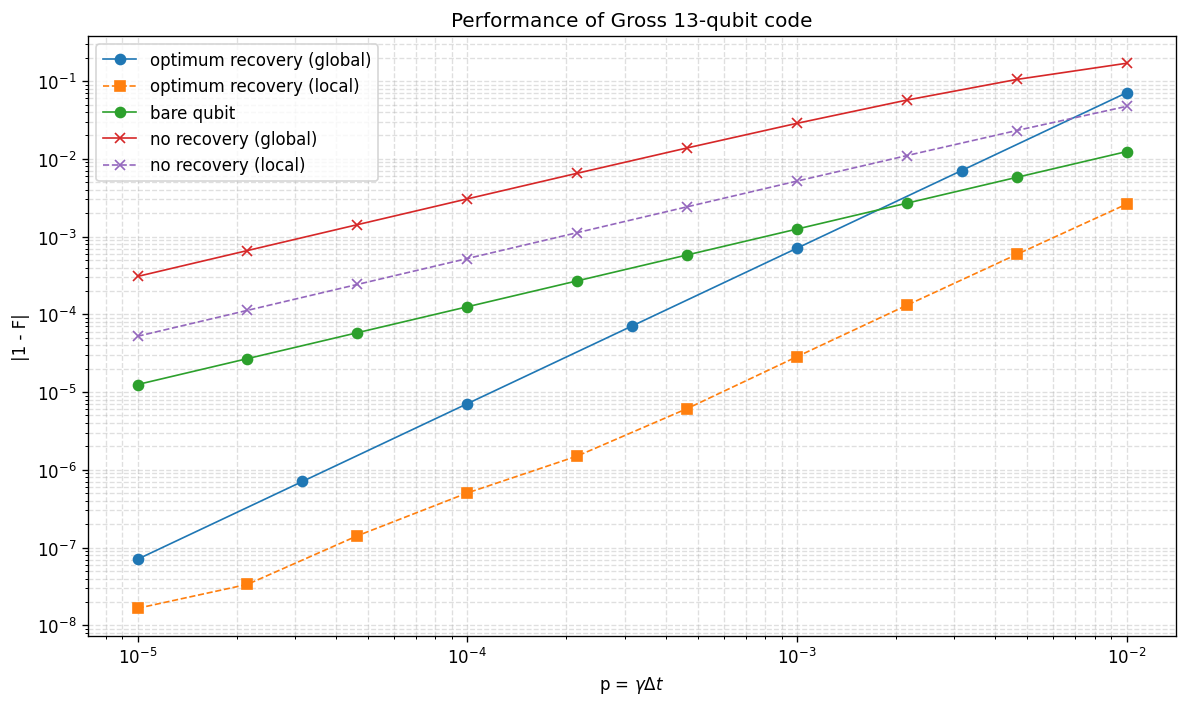

In [22]:
import numpy as np

plt.figure(figsize=(10, 6), dpi=120)

p_vals = np.logspace(-5, -2, 10)
p_vals_mat = np.array([
    1.0e-5,
    3.1622776601683795e-5,
    1.0e-4,
    3.1622776601683795e-4,
    1.0e-3,
    3.1622776601683795e-3,
    1.0e-2,
], dtype=float)

infids_global_mat = np.array([
    7.079457843841379e-8,
    7.079457843841379e-7,
    7.079457843841379e-6,
    7.079457843841379e-5,
    7.079457843841379e-4,
    7.079457843841379e-3,
    7.079457843841379e-2,
], dtype=float)

#p_vals_mat = np.log10([-5.0, -4.5, -4.0, -3.5, -3.0, -2.5, -2.0])
#infids_global_mat = np.log10([-7.15, -6.15, -5.15, -4.15, -3.15, -2.15, -1.15]) #data from matlab

# Process results
infids_global = np.array(infids_global_mat, dtype=float) #bgm code after recovery
infids_bare_global = np.array(infids_bare_global, dtype=float) #bare qubit
infids_local = np.array(infids_local, dtype=float) #bgm code after recovery
infids_norecovery_global = np.array(infids_norecovery_global, dtype=float)#bgm code without recovery
infids_norecovery_local = np.array(infids_norecovery_local, dtype=float)#bgm code without recovery

mask_global = (infids_global > 0) & np.isfinite(infids_global)
mask_local = (infids_local > 0) & np.isfinite(infids_local)
mask_bare_global = (infids_bare_global > 0) & np.isfinite(infids_bare_global)
mask_infids_norecovery_global = (infids_norecovery_global > 0) & np.isfinite(infids_norecovery_global)
mask_infids_norecovery_local = (infids_norecovery_local > 0) & np.isfinite(infids_norecovery_local)

if np.any(mask_global):
    plt.loglog(p_vals_mat[mask_global], infids_global[mask_global], "o-", lw=1, label=f"optimum recovery (global)")
if np.any(mask_local):
    plt.loglog(p_vals[mask_local], infids_local[mask_local], "s--", lw=1, label=f"optimum recovery (local)")
if np.any(mask_bare_global):
    plt.loglog(p_vals[mask_bare_global], infids_bare_global[mask_bare_global], "o-", lw=1, label="bare qubit")
if np.any(mask_infids_norecovery_global):
    plt.loglog(p_vals[mask_infids_norecovery_global], infids_norecovery_global[mask_infids_norecovery_global], "x-", lw=1, label=f"no recovery (global)")
if np.any(mask_infids_norecovery_local):
    plt.loglog(p_vals[mask_infids_norecovery_local], infids_norecovery_local[mask_infids_norecovery_local], "x--", lw=1, label=f"no recovery (local)")

plt.xlabel("p = " + r"$\gamma \Delta t$")
plt.ylabel("|1 - F|")
plt.title("Performance of Gross 13-qubit code")
plt.grid(True, which="both", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()